In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
from specparam import SpectralModel
from specparam import Bands
import neurodsp as ndp
from scipy.stats import zscore

# NeuroDSP scipy and FOOOF modules
from neurodsp import spectral




#  modules
from lfp_spike_window_analysis import *
from spe1_plotting import *
from signal_utils import * 
from spikeparam.patch.fit import Spike
from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS

### Set up

In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'

In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

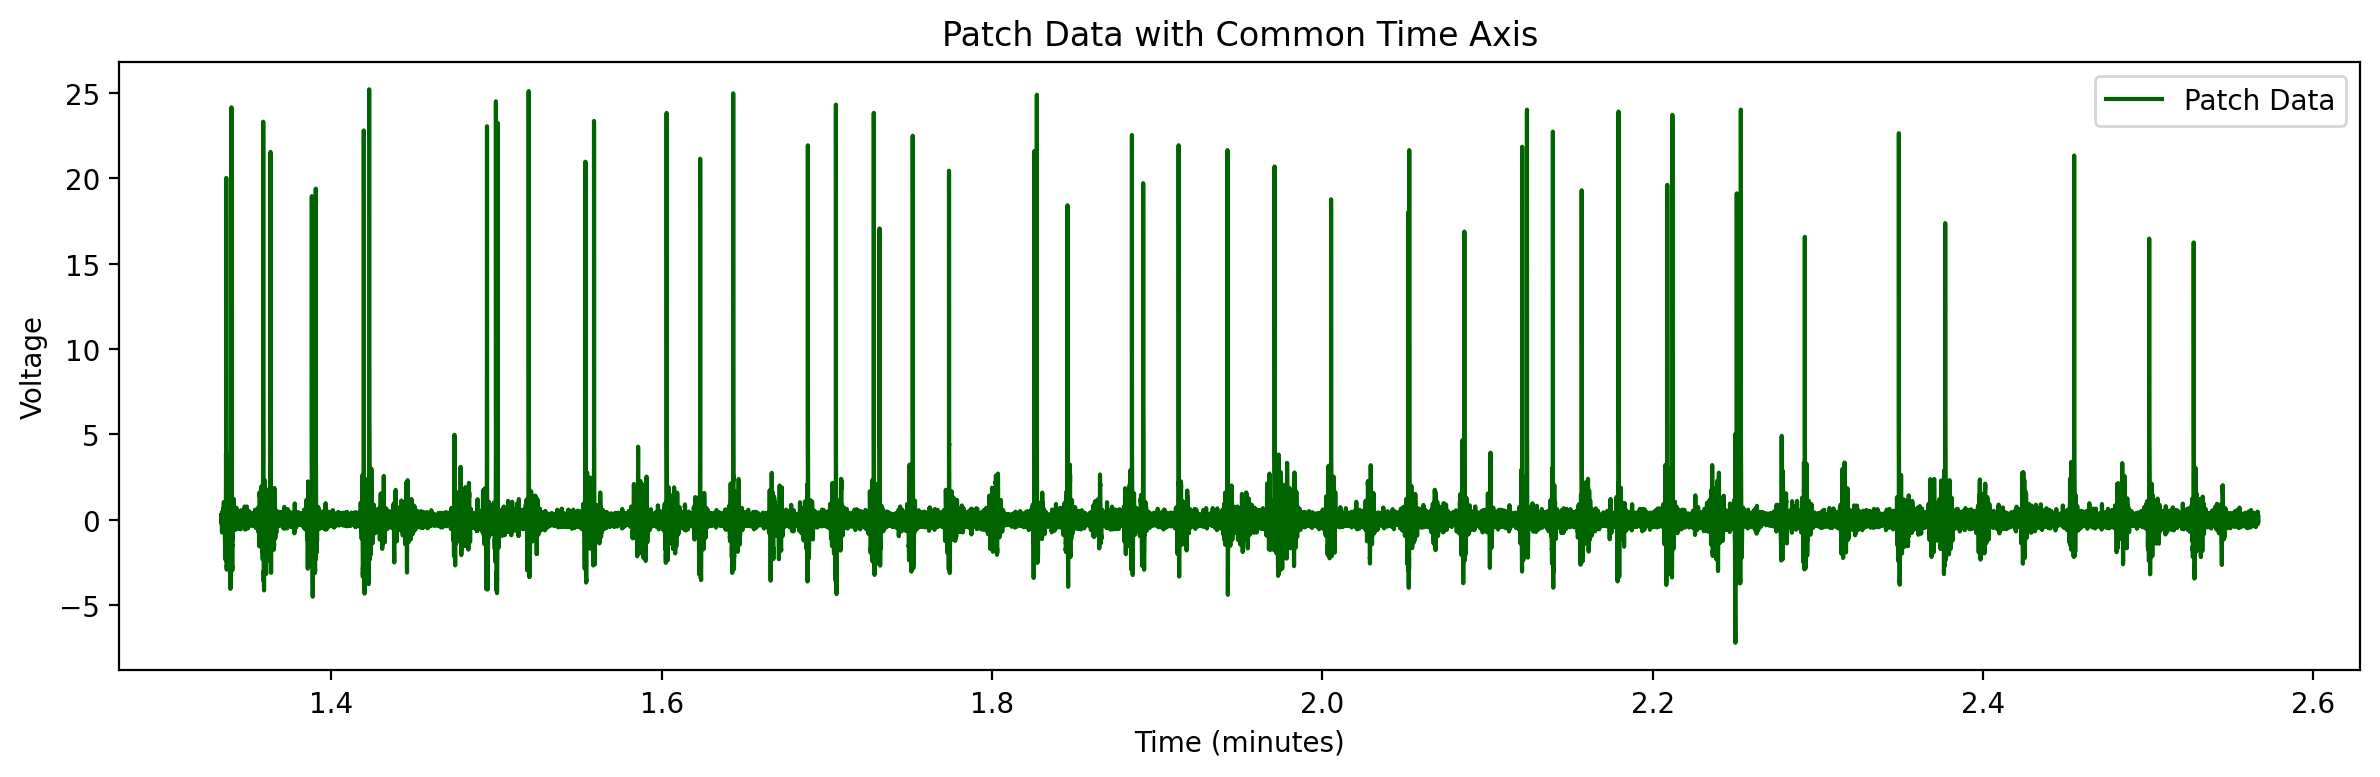

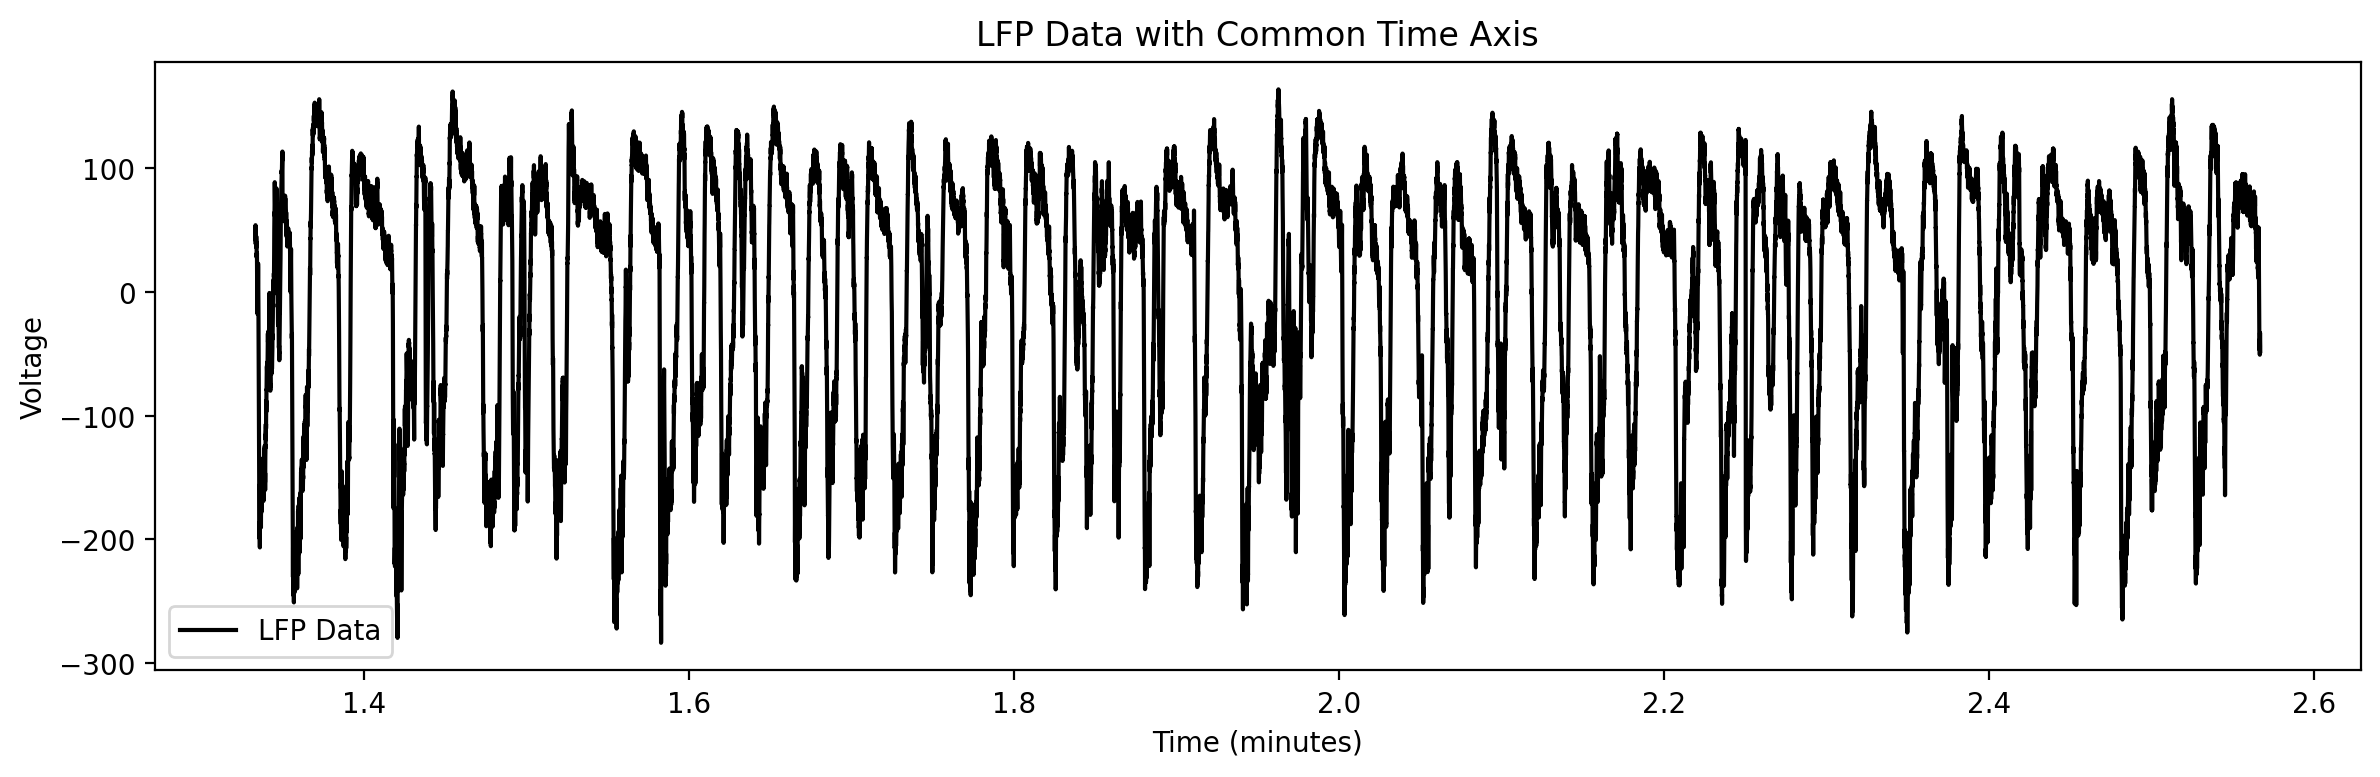

In [6]:
_ =  plot_patch_lfp_aligned(
    patch_times, patch_filt, lfp_times, lfp_filt,
    t_start_ms=80000, t_end_ms=154000
)


## STEP 1: ANALYZE LFP DATA

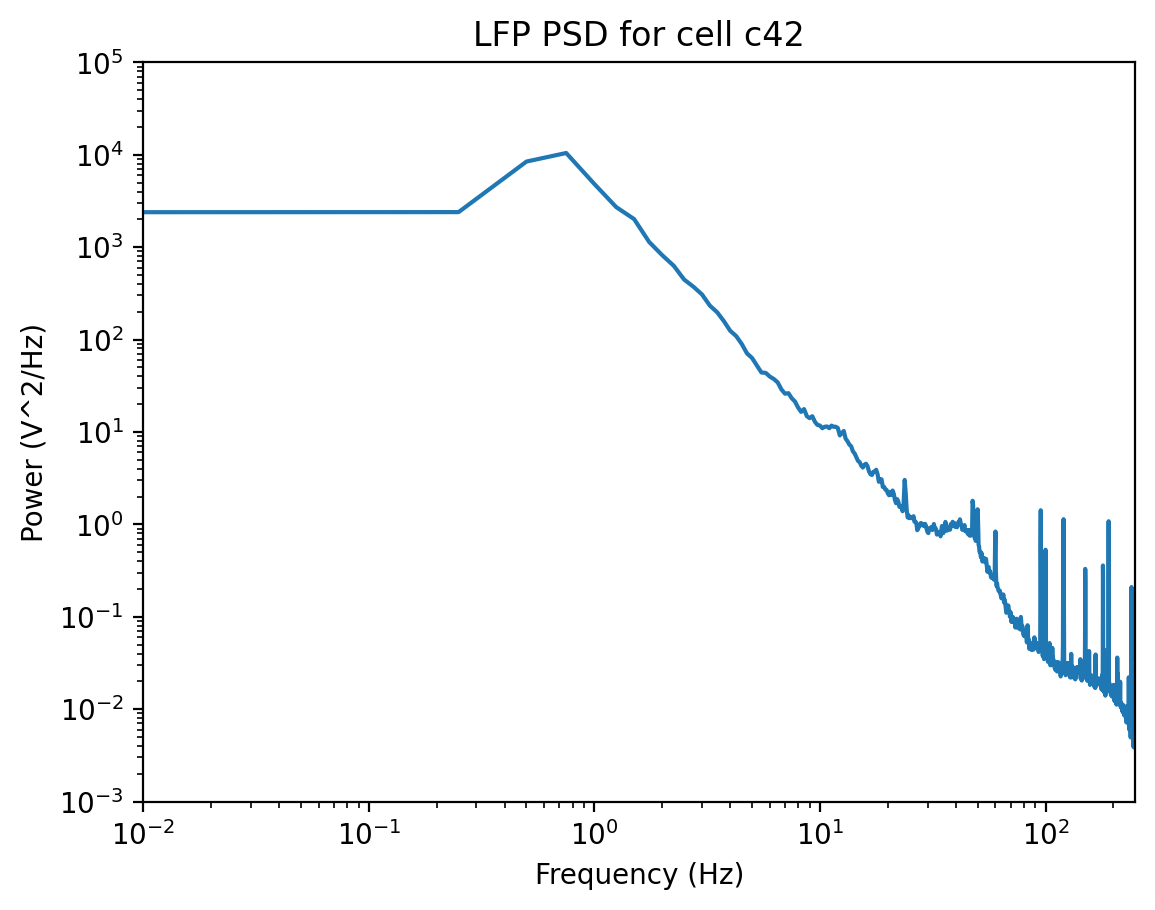

In [7]:

# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


### There seem to be some gamma oscillations 

#### 0. Use specpram to find gamma peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


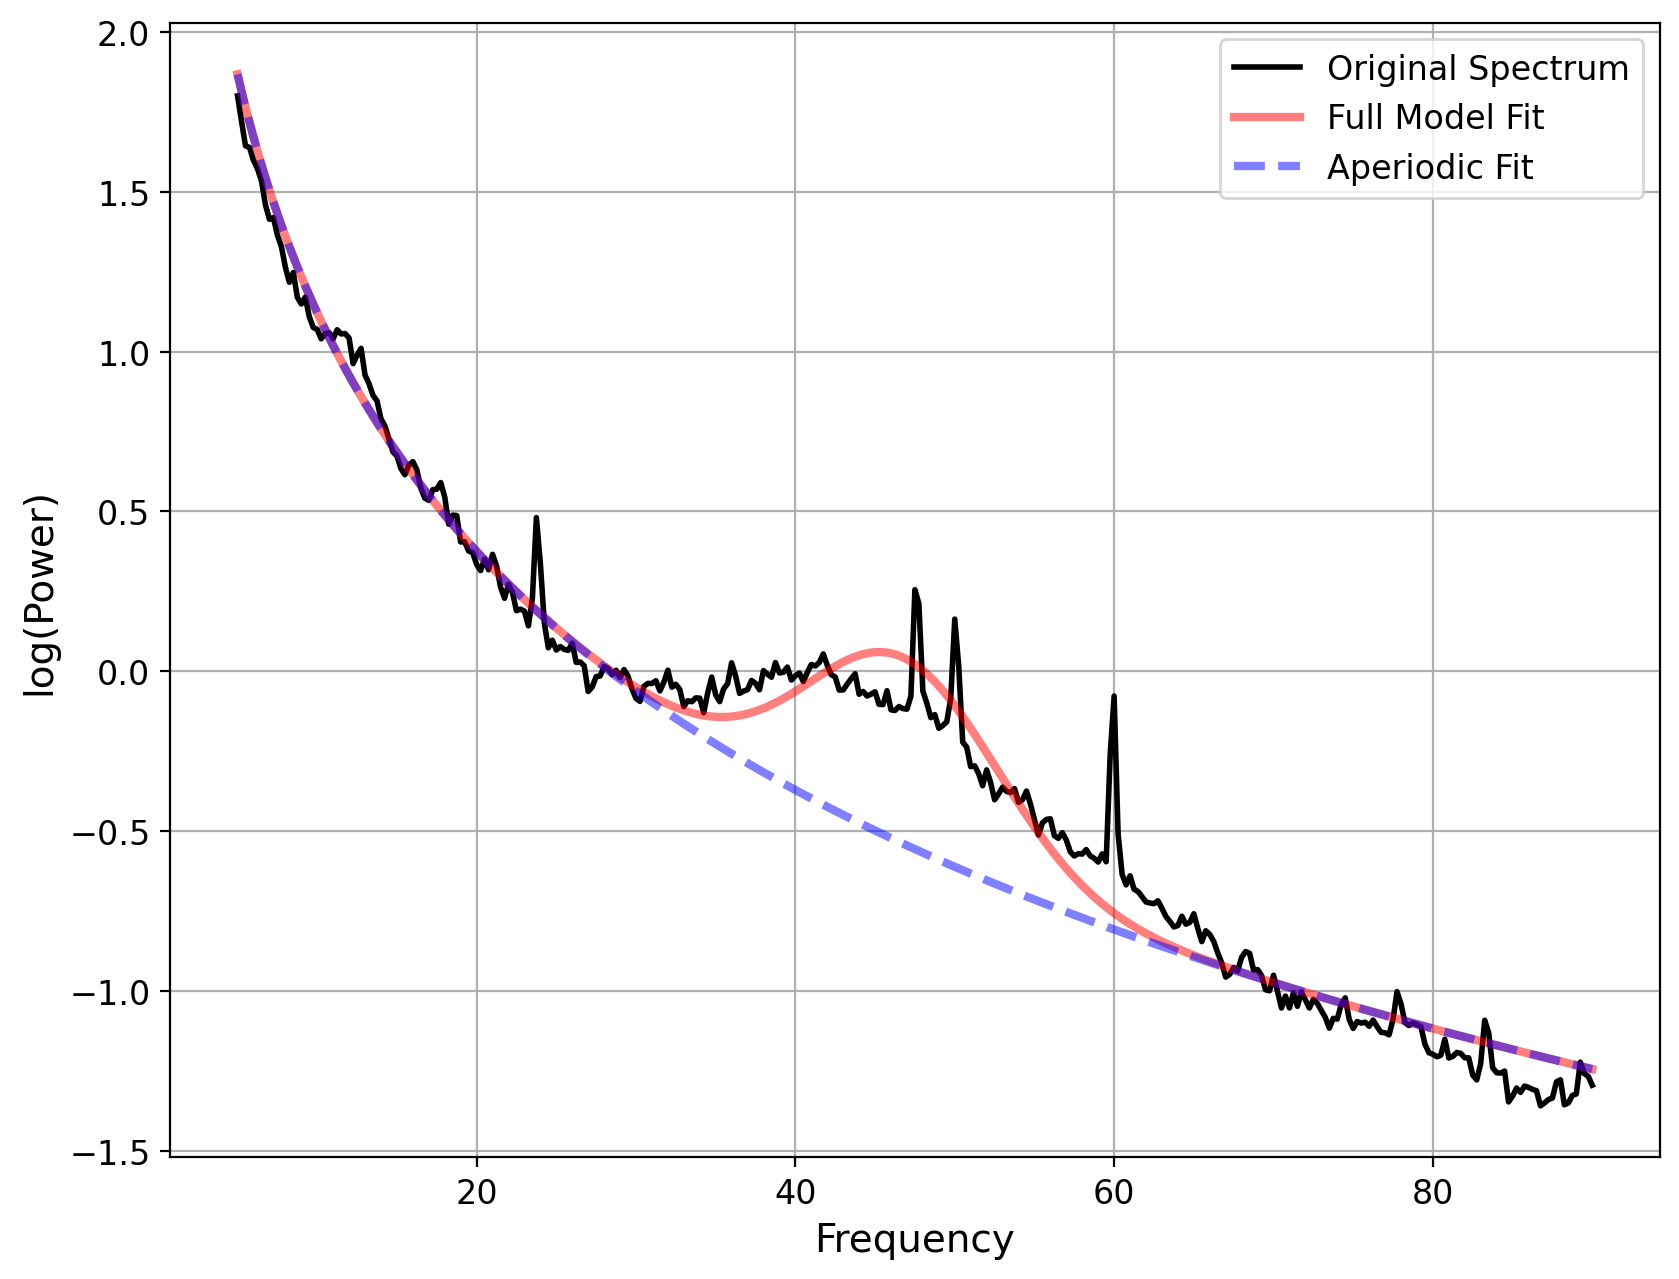

In [8]:
fm = SpectralModel(max_n_peaks=1, verbose=False)
fm.fit(fxx, pxx, freq_range=(5,90))
fm.plot()

# ANALYSIS METHOD 2) Hilbert amplitude burst for binary gamma no gamma classification 

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [9]:
gamma_peak = int(fm.peak_params_[0][0])
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma = butter_bandpass(lfp_filt, fs=lfp_fs, filt_freq=list(gamma_range), order=4)

#### 2. Get the analytic amplitude of the time series 

In [10]:
gamma_amp = ndp.timefrequency.amp_by_time(lfp_filt_gamma, lfp_fs, gamma_range)

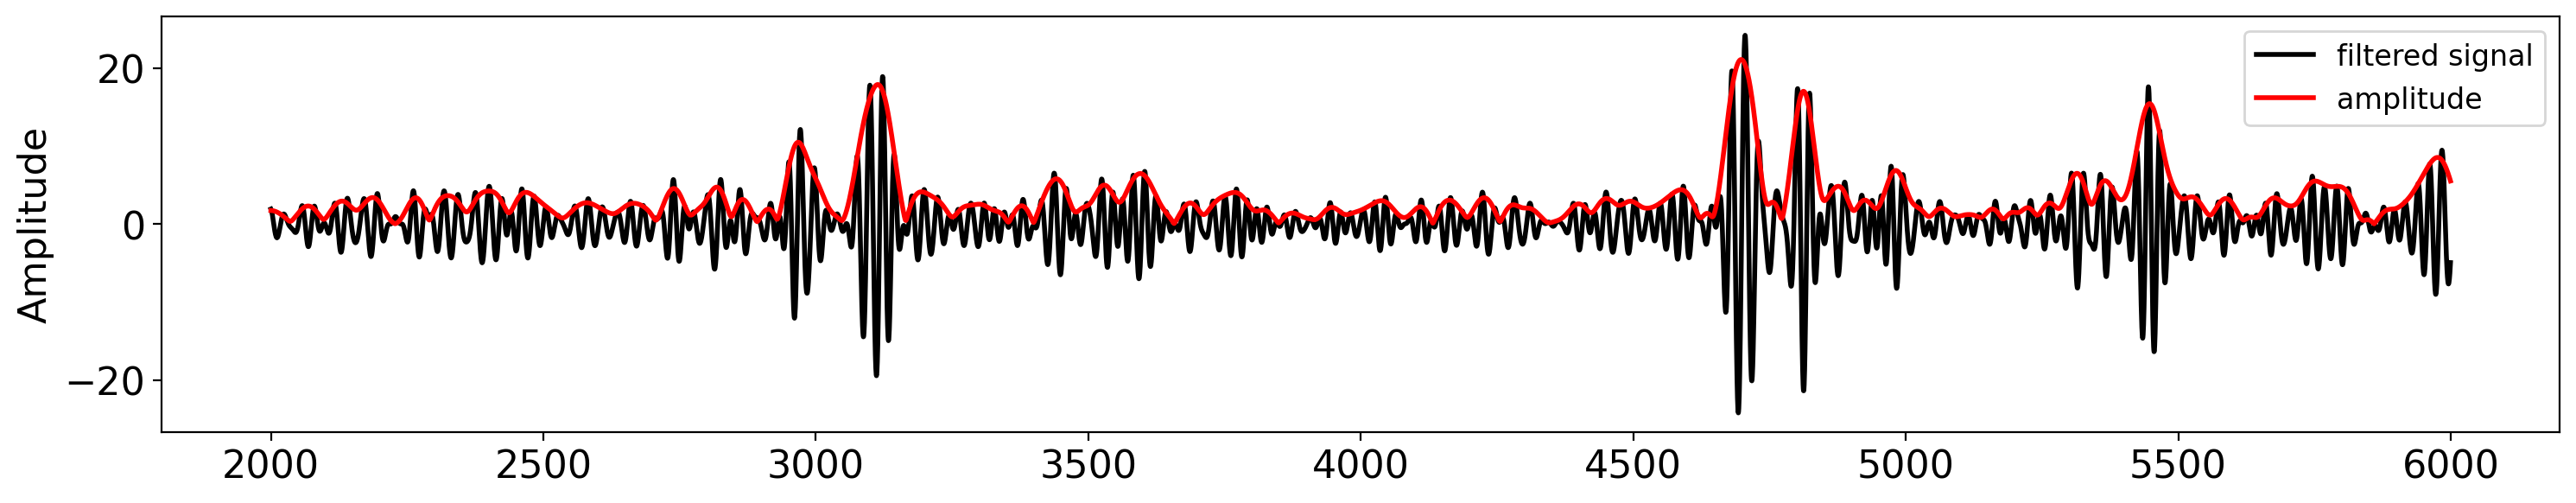

In [11]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times >= xlim[0],lfp_times < xlim[1])

# Plot the filtered signal and oscillation amplitude
ndp.plts.plot_instantaneous_measure(lfp_times[tidx], [lfp_filt_gamma[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion

In [76]:
#Detect gamma bursts (still in ms)
burst_dict = detect_gamma_bursts(
    gamma_amp=gamma_amp,
    lfp_times=lfp_times,
    high_thresh_percentile=80,
    low_thresh_percentile=20,
    min_duration_ms=50
)

#Convert burst times from ms to seconds inline (no helper function)
high_burst_win_sec = [(s / 1000, e / 1000) for s, e in burst_dict['high_bursts']]
low_burst_win_sec  = [(s / 1000, e / 1000) for s, e in burst_dict['low_bursts']]

high_burst_win = burst_dict['high_bursts']
low_burst_win = burst_dict['low_bursts']

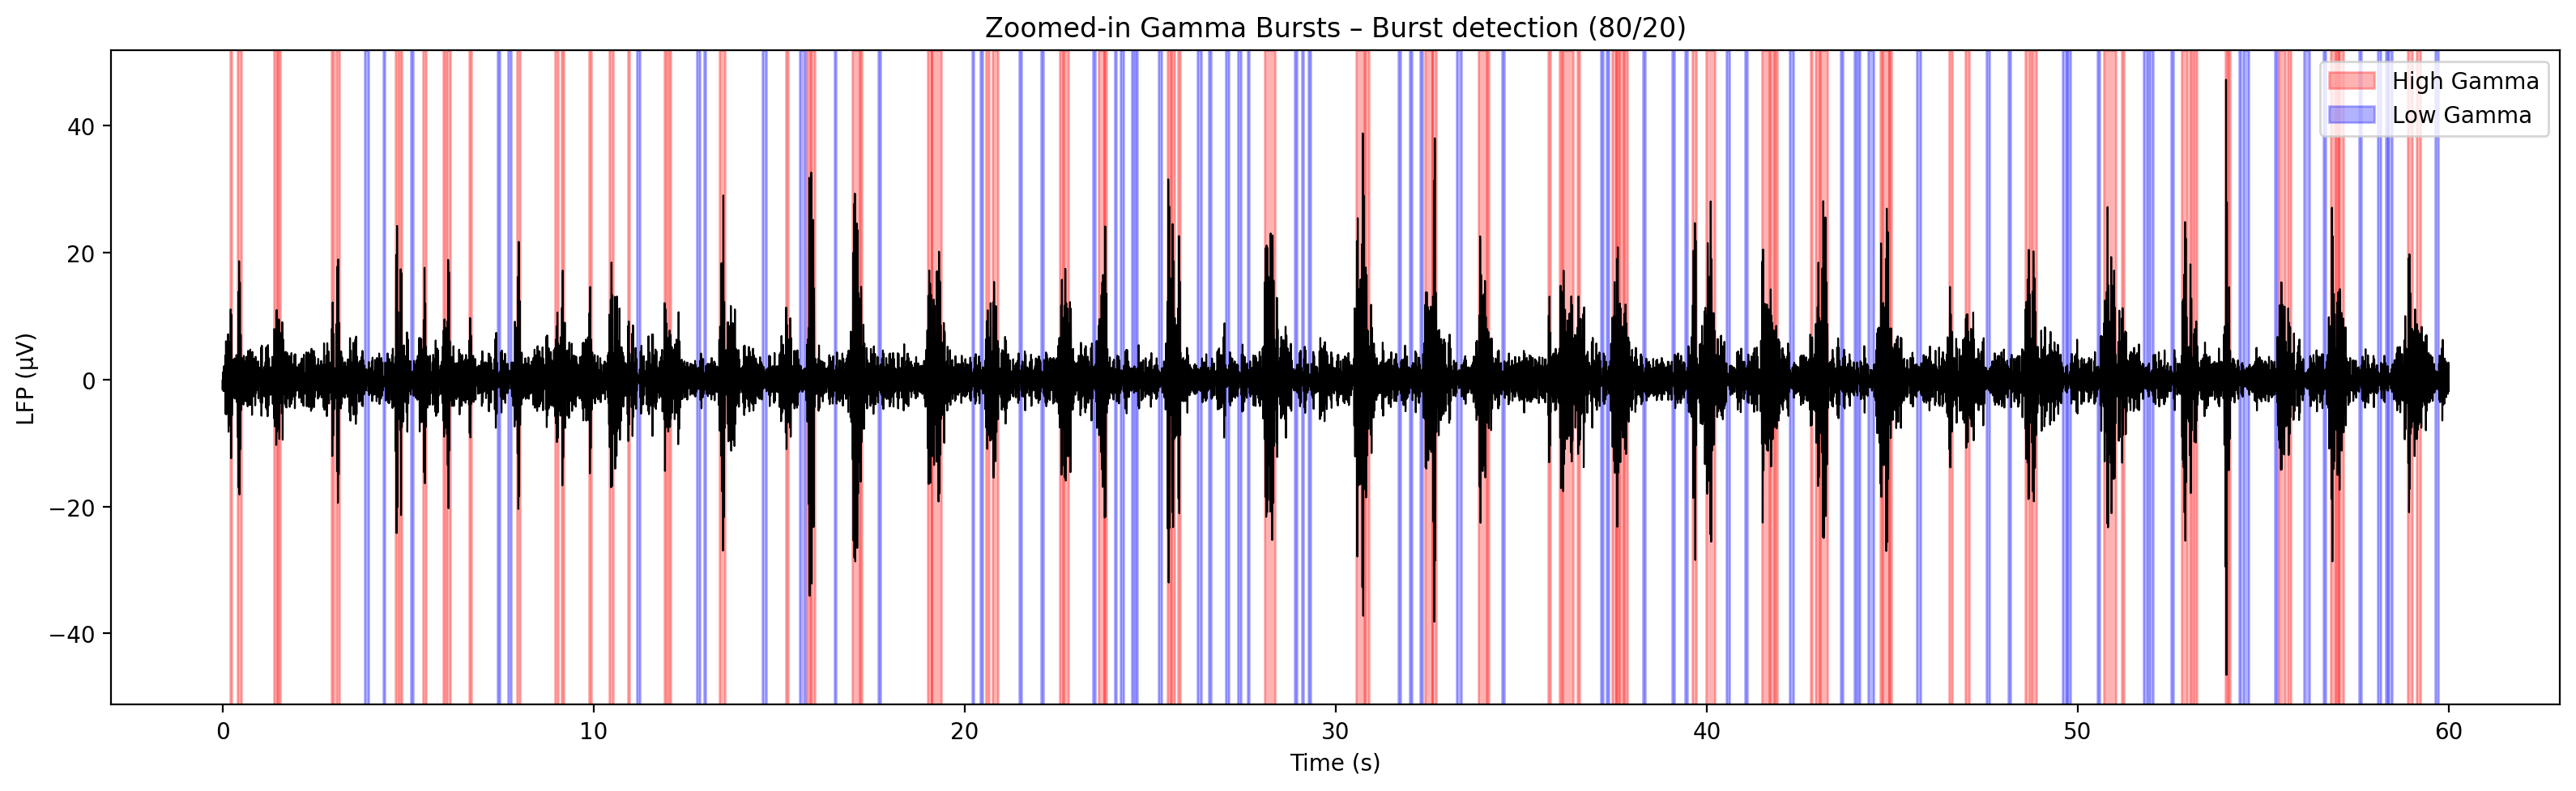

Burst detection (80/20)
High Gamma: 81 blocks | Total duration: 8.89 s
Low Gamma:  66 blocks | Total duration: 5.12 s


In [77]:
#Visualize bursts
plot_gamma_blocks_generic(
    lfp_signal=lfp_filt_gamma,
    fs=lfp_fs,
    high_blocks=high_burst_win_sec,
    low_blocks=low_burst_win_sec,
    title="Zoomed-in Gamma Bursts",
    info_label="Burst detection (80/20)",
    time_range=(0, 60)  
)




#### 4. Get longer merged blocks from the burst windows (for kilosort)


In [78]:
high_blocks = merge_burst_intervals_into_blocks(
    high_burst_win_sec,
    fs=lfp_fs,
    max_gap_sec=1.0,
    min_block_len_sec=5.0,
    units="seconds"
)

low_blocks = merge_burst_intervals_into_blocks(
    low_burst_win_sec,
    fs=lfp_fs,
    max_gap_sec=1.0,
    min_block_len_sec=5.0,
    units="seconds"
)


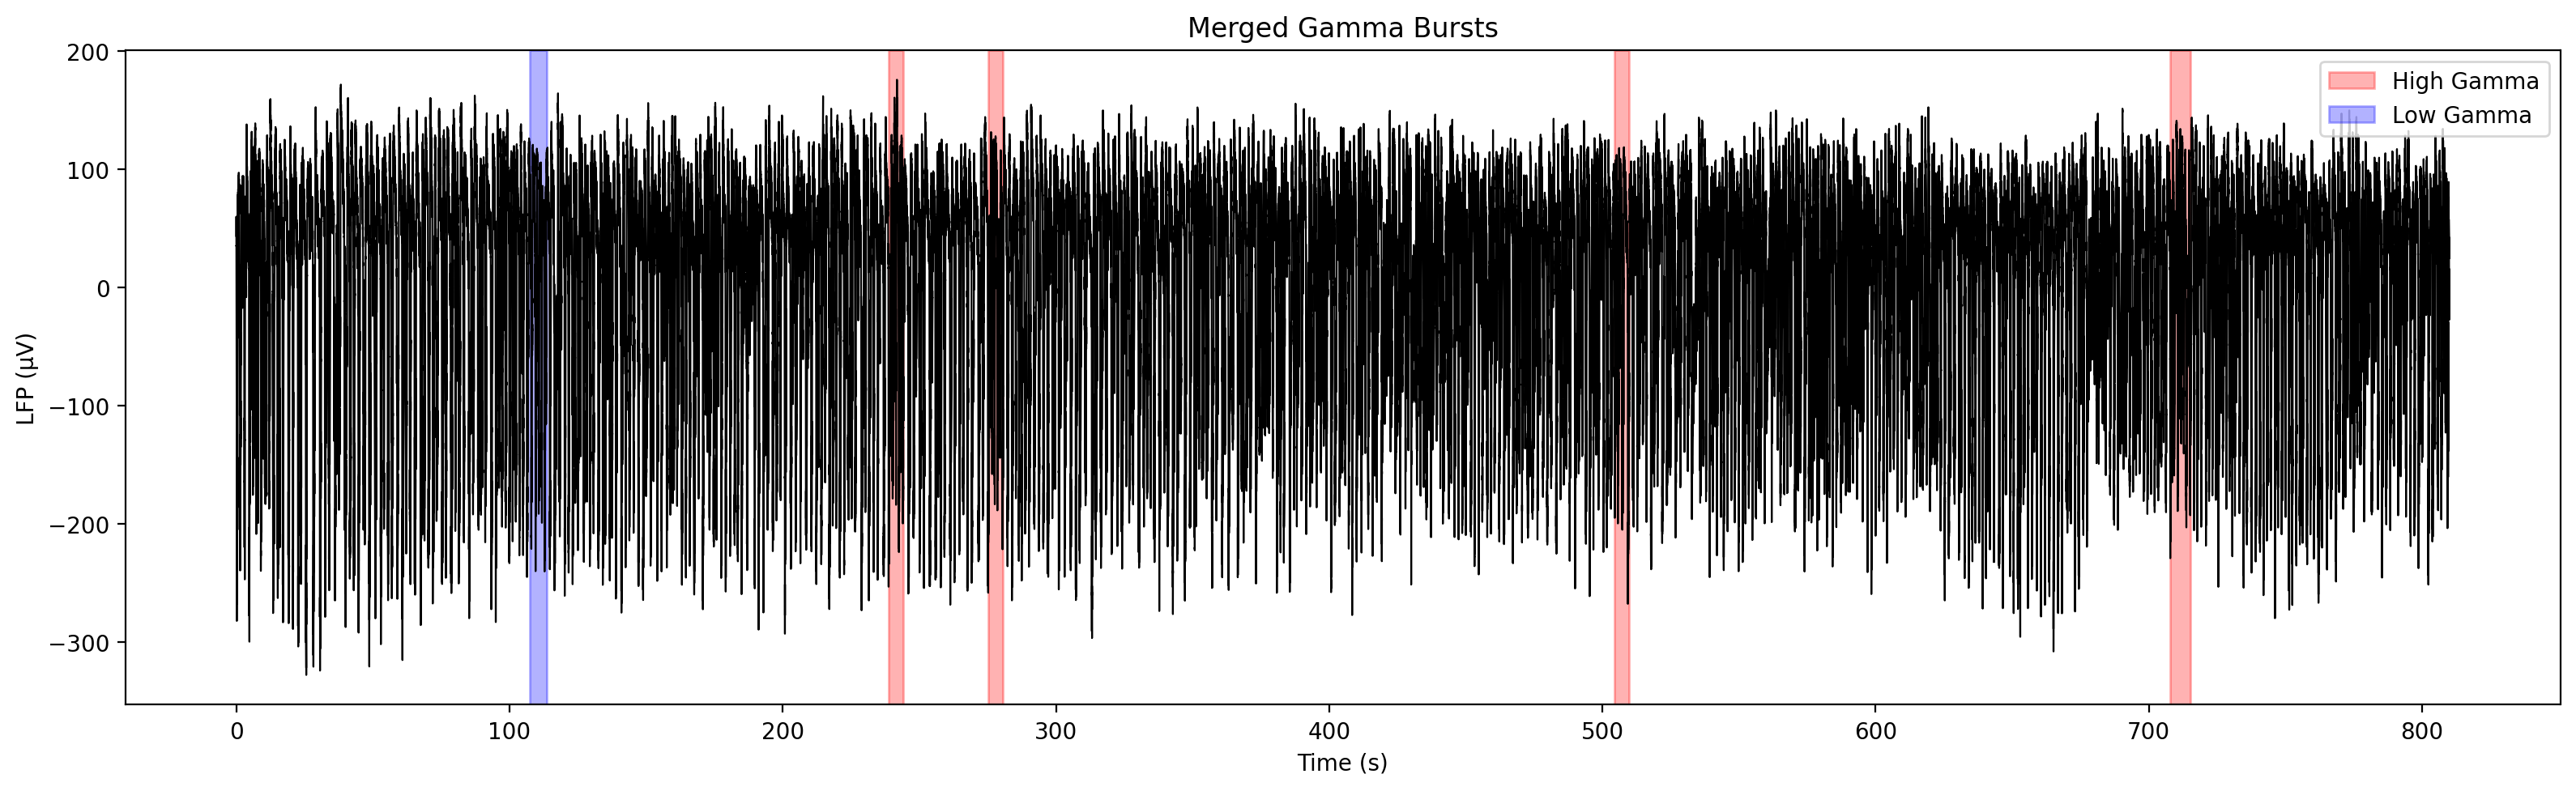

[Blocks]
High Gamma: 4 blocks | Total duration: 23.69 s
Low Gamma:  1 blocks | Total duration: 6.18 s


In [79]:
plot_gamma_blocks_generic(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    high_blocks=high_blocks,
    low_blocks=low_blocks,
    title="Merged Gamma Bursts"
)


### Save high and low blocks as bin files for kilosort  - update

In [80]:
save_bin_path = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_lfp_bins_c42_bursting_method"


save_lfp_blocks_to_bin(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    overlap_high=high_blocks,
    overlap_low=low_blocks,
    output_dir=save_bin_path
)

Saved 4 high gamma blocks and 1 low gamma blocks in:
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_lfp_bins_c42_bursting_method


# Step 2: Analyze patch spikes from high vs low windows
### Note: I am using windows instead of blocks for the patch spike comparisons because I have very few longer blocks. For the patch comparison I don't really care if the windows are not long enough (vs for the kilosort analysis that's an issue)

In [81]:
#parameterize all spikes
spk_thresh = 10
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [82]:
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/626 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [83]:
sp.filter_features()  # Applies default filters in-place

In [84]:
df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [85]:
# Label high vs low spikes based on bursting windows 
spike_df_high_low = label_spikes(df_features, high_burst_win_sec, "high", low_burst_win_sec, "low")
spike_df_high_control = label_spikes(df_features, high_burst_win_sec, "high")


Group 'Spikes in high gamma windows' → 398 spikes
Group 'Spikes in low gamma windows' → 1 spikes


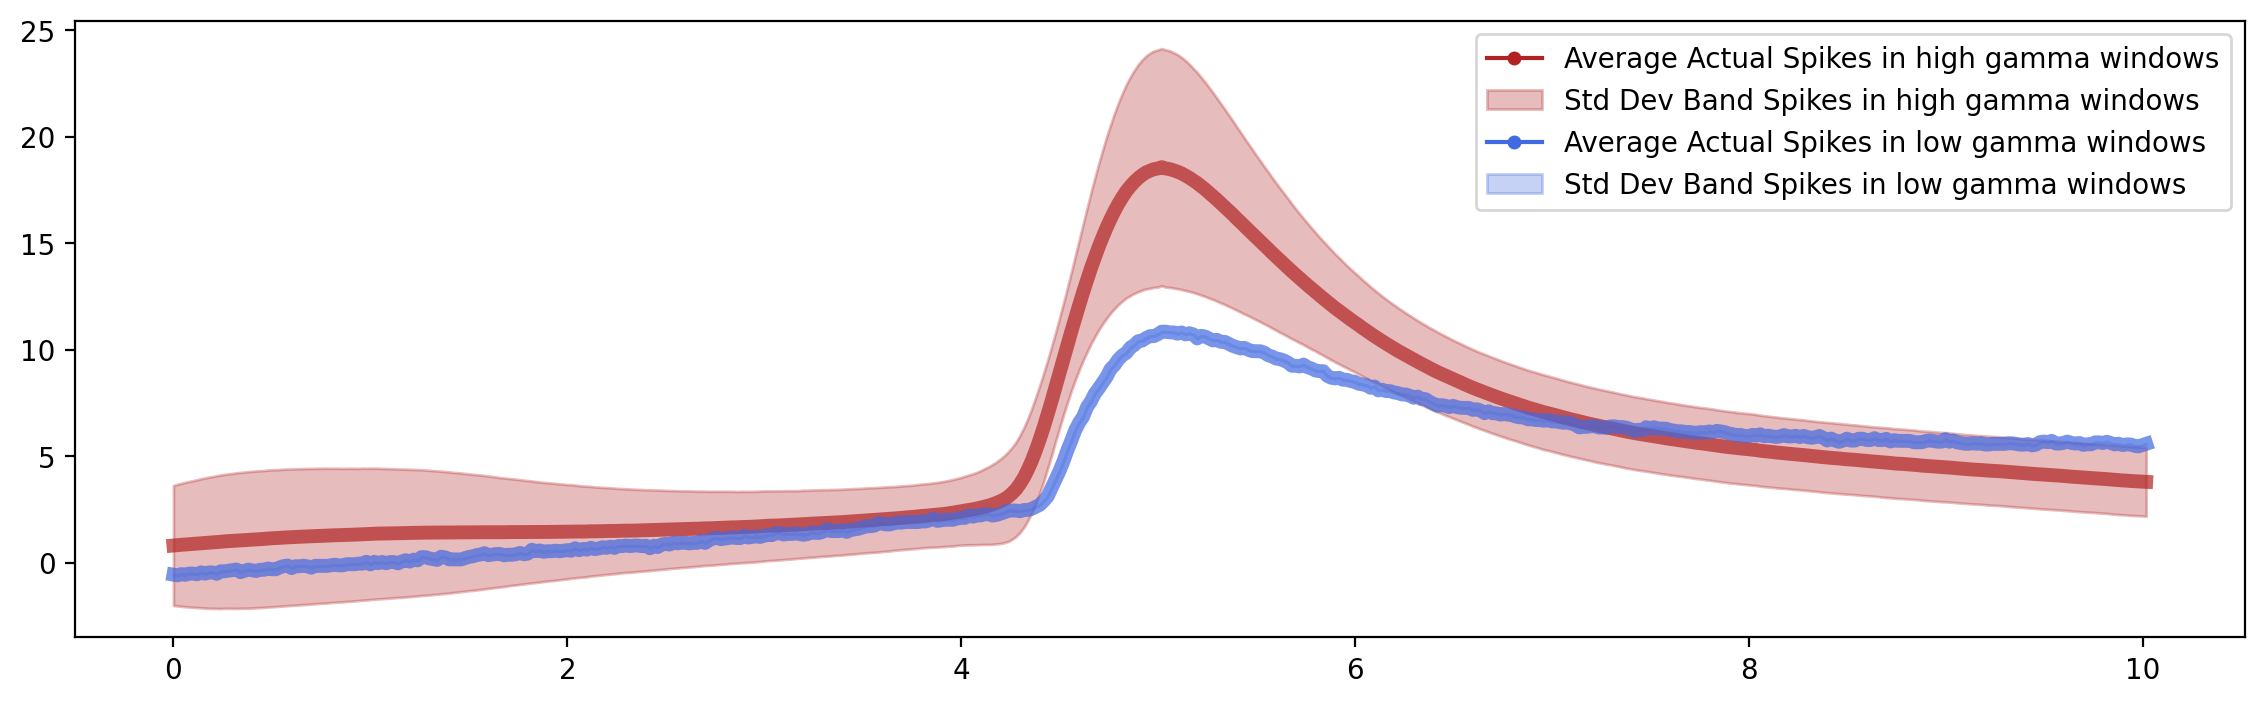

In [87]:
plot_spike_groups_from_labels(
    sp,
    spike_df_high_low,
    label_column="method_block_label",
    label_groups=["high", "low"],
    group_names=["Spikes in high gamma windows", "Spikes in low gamma windows",]
)


Ok so, I don't have enough spikes in the low gamma windows to do any comparison, so moving forward in the notebook I will compare spikes in high gamma burst windows vs controls (the rest of the spikes basically)

Group 'Spikes in high gamma windows' → 398 spikes
Group 'Spikes not in high gamma windows' → 213 spikes


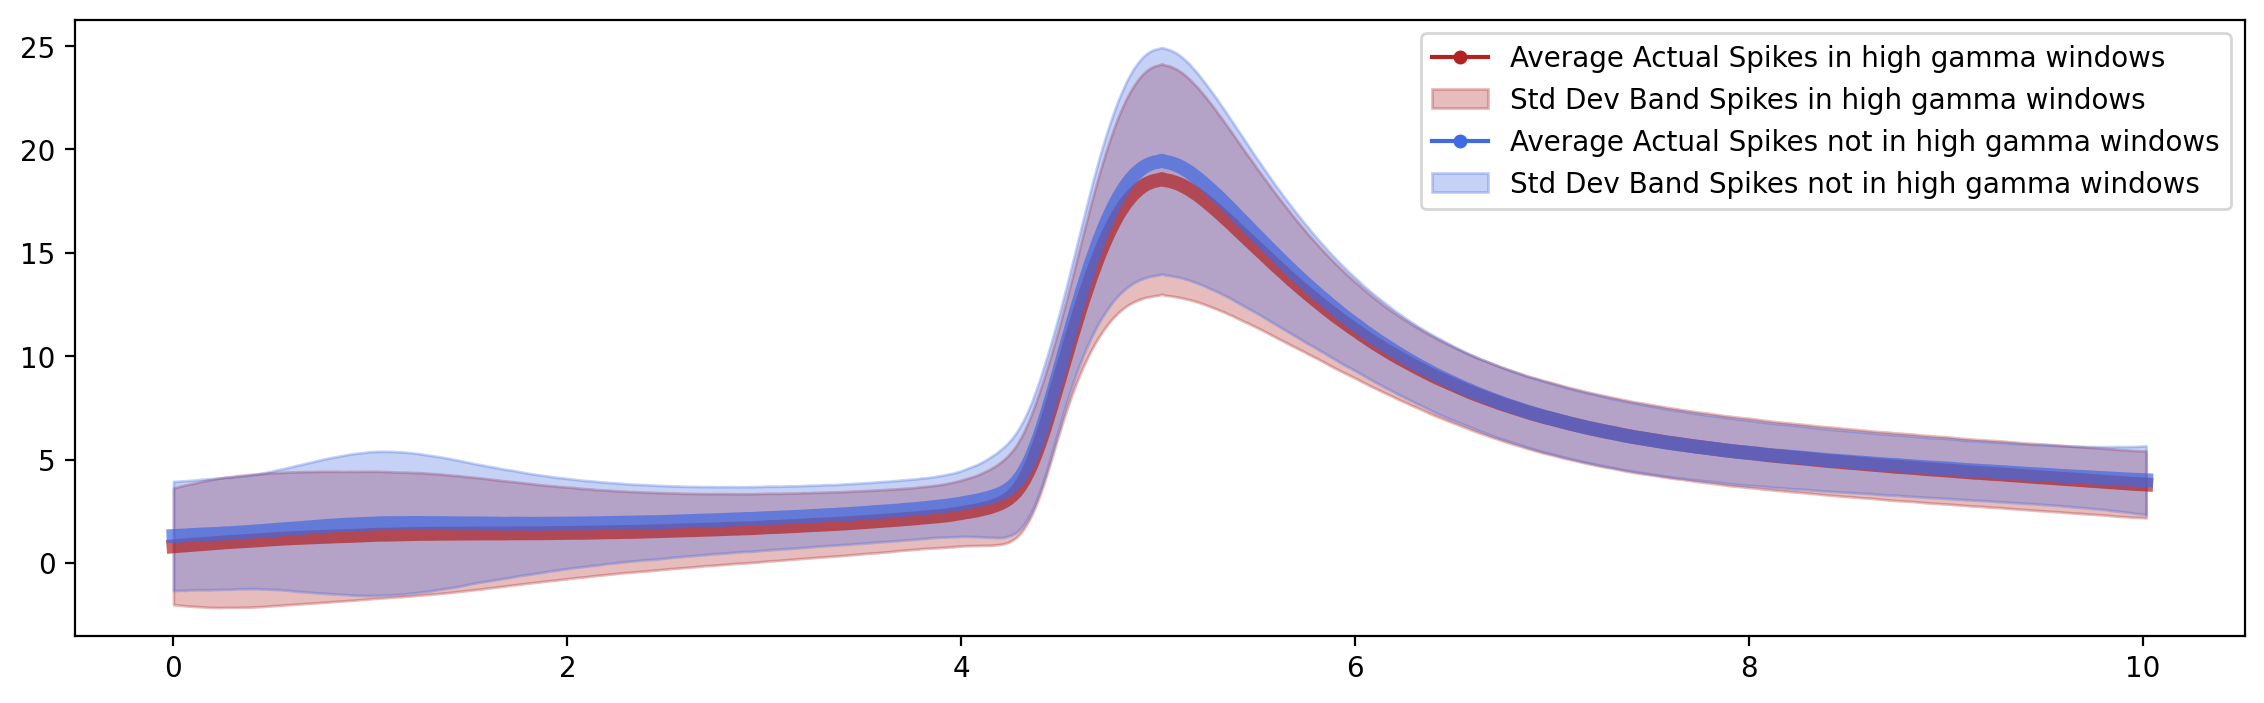

In [90]:
plot_spike_groups_from_labels(
    sp,
    spike_df_high_control,
    label_column="method_block_label",
    label_groups=["high", "none"],
    group_names=["Spikes in high gamma windows", "Spikes not in high gamma windows",]
)


In [92]:
compare_spike_params_groups(
    spike_df_high_control,
    group_col="method_block_label",
    groups=("high", "low_none"),
    params=spike_df_high_control.columns[:-4]
)


⚠️ Skipping ramp_amp – one of the groups has no data.
⚠️ Skipping inflection_time – one of the groups has no data.
⚠️ Skipping inflection_amp – one of the groups has no data.
⚠️ Skipping peak_amp – one of the groups has no data.
⚠️ Skipping peak_width – one of the groups has no data.
⚠️ Skipping peak_sharpness – one of the groups has no data.
⚠️ Skipping exp_lambda – one of the groups has no data.
⚠️ Skipping exp_const – one of the groups has no data.
⚠️ Skipping log_isi – one of the groups has no data.


{}